# Tugas Implementasi Transformer
**Nama:** Nada Nadhira Najwa Mazaya 
**NIM:** 256150100111005

## 1. Import Library dan Set Device

In [34]:
import time
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from datasets import load_dataset

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR

# torchvision untuk image tasks
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models

# sklearn untuk evaluasi
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Ultralytics untuk YOLO (object detection)
try:
    from ultralytics import YOLO
    print("Ultralytics YOLO tersedia")
except ImportError:
    print("Install ultralytics: pip install ultralytics")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Semua library berhasil diimport!")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Ultralytics YOLO tersedia
Semua library berhasil diimport!
PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130


Set Device

In [35]:
# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Memory GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("CUDA tidak tersedia, menggunakan CPU")

Device yang digunakan: cuda
GPU: NVIDIA GeForce RTX 5070
CUDA Version: 13.0
Memory GPU: 12.34 GB


In [36]:
# Helper function: Hitung jumlah parameter model
def count_parameters(model):
    """Hitung jumlah parameter yang dapat dilatih"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Helper function: Train model
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Training satu epoch"""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

# Helper function: Evaluate model
def evaluate(model, dataloader, criterion, device):
    """Evaluasi model pada test set"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels)

## 2. Text Classification: AG News Dataset + Preprocessing

In [37]:
# Load AG News dataset
print("Loading AG News dataset...")
dataset = load_dataset("ag_news")
print(f"Dataset info: {dataset}")
print(f"Train samples: {len(dataset['train'])}")
print(f"Test samples: {len(dataset['test'])}")

# Sample data
print("\nSample dari train set:")
for i in range(2):
    print(f"Text: {dataset['train'][i]['text'][:100]}...")
    print(f"Label: {dataset['train'][i]['label']} (0:World, 1:Sports, 2:Business, 3:Sci/Tech)\n")

Loading AG News dataset...
Dataset info: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train samples: 120000
Test samples: 7600

Sample dari train set:
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
Label: 2 (0:World, 1:Sports, 2:Business, 3:Sci/Tech)

Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...
Label: 2 (0:World, 1:Sports, 2:Business, 3:Sci/Tech)



## Pre-processing Text

In [38]:
# Preprocessing text dengan built-in tokenizer sederhana
import re
from collections import Counter

def simple_tokenize(text):
    """Tokenization sederhana: lowercase, hapus punctuation, split by space"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Build vocabulary dari training set
print("Building vocabulary...")
vocab = Counter()
max_len = 0

for sample in dataset['train']:
    tokens = simple_tokenize(sample['text'])
    vocab.update(tokens)
    max_len = max(max_len, len(tokens))

# Ambil top 5000 tokens sebagai vocabulary
vocab_size = 5000
vocab_list = [word for word, _ in vocab.most_common(vocab_size)]
word2idx = {word: idx + 2 for idx, word in enumerate(vocab_list)}  # +2 untuk padding (0) dan UNK (1)
idx2word = {idx: word for word, idx in word2idx.items()}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1

print(f"Vocabulary size: {len(word2idx)}")
print(f"Max sequence length in training: {max_len}")
print(f"Limiting to max_seq_len=256")

# Set max sequence length
MAX_SEQ_LEN = 256

def encode_text(text, word2idx, max_len):
    """Encode text to indices"""
    tokens = simple_tokenize(text)
    indices = [word2idx.get(token, 1) for token in tokens]  # 1 adalah UNK
    
    # Padding atau truncate
    if len(indices) < max_len:
        indices = indices + [0] * (max_len - len(indices))  # 0 adalah PAD
    else:
        indices = indices[:max_len]
    
    return np.array(indices, dtype=np.int64)

# Encode training dan test set
print("\nEncoding text data...")
train_texts = np.array([encode_text(sample['text'], word2idx, MAX_SEQ_LEN) for sample in dataset['train']])
train_labels = np.array(dataset['train']['label'])

test_texts = np.array([encode_text(sample['text'], word2idx, MAX_SEQ_LEN) for sample in dataset['test']])
test_labels = np.array(dataset['test']['label'])

print(f"Train texts shape: {train_texts.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test texts shape: {test_texts.shape}")
print(f"Test labels shape: {test_labels.shape}")

# Ambil subset untuk training yang lebih cepat (opsional - untuk eksperimen cepat)
# Uncomment jika ingin subset
# TRAIN_SIZE = 5000
# train_texts = train_texts[:TRAIN_SIZE]
# train_labels = train_labels[:TRAIN_SIZE]

# Create DataLoader
BATCH_SIZE = 32

train_dataset_text = TensorDataset(torch.tensor(train_texts), torch.tensor(train_labels))
test_dataset_text = TensorDataset(torch.tensor(test_texts), torch.tensor(test_labels))

train_loader_text = DataLoader(train_dataset_text, batch_size=BATCH_SIZE, shuffle=True)
test_loader_text = DataLoader(test_dataset_text, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoader created:")
print(f"  Train batches: {len(train_loader_text)}")
print(f"  Test batches: {len(test_loader_text)}")

Building vocabulary...
Vocabulary size: 5002
Max sequence length in training: 176
Limiting to max_seq_len=256

Encoding text data...
Train texts shape: (120000, 256)
Train labels shape: (120000,)
Test texts shape: (7600, 256)
Test labels shape: (7600,)

DataLoader created:
  Train batches: 3750
  Test batches: 238


## 3. Text Transformer Model

In [39]:
class TransformerTextClassifier(nn.Module):
    """
    Transformer untuk Text Classification
    Arsitektur:
    Input -> Embedding -> Positional Encoding -> Transformer Encoder -> Pooling -> Linear -> Output
    """
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len, num_classes, dropout=0.1):
        super(TransformerTextClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.positional_encoding = nn.Parameter(torch.randn(1, max_seq_len, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        
        # Add positional encoding
        embedded = embedded + self.positional_encoding[:, :embedded.size(1), :]
        embedded = self.dropout(embedded)
        
        # Create padding mask
        mask = (x == 0)  # True untuk padding tokens
        
        # Transformer encoder
        transformer_out = self.transformer_encoder(embedded, src_key_padding_mask=mask)
        
        # Pooling: mean pooling dari semua token kecuali padding
        mask_expanded = mask.unsqueeze(-1).expand(transformer_out.size())
        sum_out = (transformer_out * (~mask_expanded)).sum(dim=1)
        count = (~mask).sum(dim=1, keepdim=True)
        pooled = sum_out / count
        
        # Classification
        logits = self.fc(pooled)
        return logits

# Model hyperparameters
EMBED_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 2
NUM_CLASSES = 4  # AG News has 4 classes

# Create model
model_transformer_text = TransformerTextClassifier(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    max_seq_len=MAX_SEQ_LEN,
    num_classes=NUM_CLASSES
).to(device)

print(f"Transformer Text Model created!")
print(f"Total parameters: {count_parameters(model_transformer_text)}")
print(f"Model:\n{model_transformer_text}")

Transformer Text Model created!
Total parameters: 938500
Model:
TransformerTextClassifier(
  (embedding): Embedding(5002, 128, padding_idx=0)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## 4. Bidirectional LSTM dengan Attention (Model Pembanding Text)

In [40]:
class Attention(nn.Module):
    """Attention mechanism untuk LSTM"""
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def forward(self, lstm_output, mask=None):
        """
        lstm_output: (batch_size, seq_len, hidden_size)
        mask: (batch_size, seq_len) untuk padding tokens
        return: context vector (batch_size, hidden_size)
        """
        # Calculate attention weights
        scores = self.attention(lstm_output)  # (batch_size, seq_len, 1)
        scores = scores.squeeze(-1)  # (batch_size, seq_len)
        
        # Apply mask untuk padding tokens
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))
        
        # Apply softmax
        attention_weights = F.softmax(scores, dim=1)  # (batch_size, seq_len)
        
        # Apply attention weights ke LSTM output
        attention_weights = attention_weights.unsqueeze(1)  # (batch_size, 1, seq_len)
        context = torch.bmm(attention_weights, lstm_output).squeeze(1)  # (batch_size, hidden_size)
        
        return context

class BiLSTMAttentionTextClassifier(nn.Module):
    """
    Bidirectional LSTM dengan Attention untuk Text Classification
    Arsitektur:
    Input -> Embedding -> BiLSTM -> Attention -> Linear -> Output
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes, dropout=0.1):
        super(BiLSTMAttentionTextClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_embed = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.attention = Attention(hidden_size * 2)  # *2 karena bidirectional
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        embedded = self.dropout_embed(embedded)
        
        # LSTM
        lstm_output, _ = self.lstm(embedded)  # (batch_size, seq_len, hidden_size*2)
        
        # Create mask untuk padding tokens
        mask = (x == 0)  # True untuk padding
        
        # Attention
        context = self.attention(lstm_output, mask)  # (batch_size, hidden_size*2)
        
        # Classification
        hidden = F.relu(self.fc1(context))
        hidden = self.dropout(hidden)
        logits = self.fc2(hidden)
        
        return logits

# Model hyperparameters
HIDDEN_SIZE = 64
LSTM_LAYERS = 2

# Create model
model_bilstm_text = BiLSTMAttentionTextClassifier(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=LSTM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)

print(f"BiLSTM Attention Text Model created!")
print(f"Total parameters: {count_parameters(model_bilstm_text)}")
print(f"Model:\n{model_bilstm_text}")

BiLSTM Attention Text Model created!
Total parameters: 847557
Model:
BiLSTMAttentionTextClassifier(
  (embedding): Embedding(5002, 128, padding_idx=0)
  (dropout_embed): Dropout(p=0.1, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=128, out_features=1, bias=True)
  )
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [41]:
class LSTMBidirectionalTextClassifier(nn.Module):
    """
    Standard Bidirectional LSTM untuk Text Classification (tanpa Attention)
    Arsitektur:
    Input -> Embedding -> BiLSTM -> Linear -> Output
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, num_classes, dropout=0.1):
        super(LSTMBidirectionalTextClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout_embed = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc1 = nn.Linear(hidden_size * 2, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        embedded = self.dropout_embed(embedded)
        
        # LSTM - use only last hidden state
        lstm_output, (hidden, cell) = self.lstm(embedded)  # hidden: (2, batch_size, hidden_size)
        
        # Concatenate bidirectional outputs dari last layer
        last_hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (batch_size, hidden_size*2)
        
        # Classification
        hidden = F.relu(self.fc1(last_hidden))
        hidden = self.dropout(hidden)
        logits = self.fc2(hidden)
        
        return logits

# Create model
model_lstm_text = LSTMBidirectionalTextClassifier(
    vocab_size=len(word2idx),
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=LSTM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)

print(f"LSTM Bidirectional Text Model created!")
print(f"Total parameters: {count_parameters(model_lstm_text)}")
print(f"Model:\n{model_lstm_text}")

LSTM Bidirectional Text Model created!
Total parameters: 847428
Model:
LSTMBidirectionalTextClassifier(
  (embedding): Embedding(5002, 128, padding_idx=0)
  (dropout_embed): Dropout(p=0.1, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


## 5. Training dan Evaluation Text Models

In [42]:
# Training setup untuk text models
NUM_EPOCHS = 5
LEARNING_RATE_TEXT = 1e-3
criterion = nn.CrossEntropyLoss()

optimizer_transformer = optim.Adam(
    model_transformer_text.parameters(),
    lr=LEARNING_RATE_TEXT
)
optimizer_bilstm = optim.Adam(
    model_bilstm_text.parameters(),
    lr=LEARNING_RATE_TEXT
)

history_transformer = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

history_bilstm = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Text training setup selesai")
print(f"  NUM_EPOCHS = {NUM_EPOCHS}")
print(f"  Learning rate = {LEARNING_RATE_TEXT}")

Text training setup selesai
  NUM_EPOCHS = 5
  Learning rate = 0.001


In [43]:
start_time_transformer = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_transformer_text, train_loader_text, optimizer_transformer, criterion, device)
    test_loss, test_acc, _, _ = evaluate(model_transformer_text, test_loader_text, criterion, device)
    epoch_time = time.time() - epoch_start_time
    
    history_transformer['train_loss'].append(train_loss)
    history_transformer['train_acc'].append(train_acc)
    history_transformer['test_loss'].append(test_loss)
    history_transformer['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_transformer = time.time() - start_time_transformer
print(f"\nTraining time: {time_transformer:.2f} seconds")

# Get final predictions untuk confusion matrix
_, _, y_pred_transformer, y_true_transformer = evaluate(model_transformer_text, test_loader_text, criterion, device)
final_test_acc_transformer = accuracy_score(y_true_transformer, y_pred_transformer)
print(f"Final Test Accuracy: {final_test_acc_transformer:.4f}")

Epoch 1/5 | Waktu: 41.55s | Train Loss: 0.4597 | Train Acc: 0.8326 | Test Loss: 0.3253 | Test Acc: 0.8893
Epoch 2/5 | Waktu: 41.40s | Train Loss: 0.2954 | Train Acc: 0.8983 | Test Loss: 0.2971 | Test Acc: 0.9020
Epoch 3/5 | Waktu: 41.71s | Train Loss: 0.2599 | Train Acc: 0.9103 | Test Loss: 0.2843 | Test Acc: 0.9028
Epoch 4/5 | Waktu: 45.28s | Train Loss: 0.2386 | Train Acc: 0.9175 | Test Loss: 0.2734 | Test Acc: 0.9061
Epoch 5/5 | Waktu: 46.53s | Train Loss: 0.2237 | Train Acc: 0.9215 | Test Loss: 0.2781 | Test Acc: 0.9066

Training time: 216.48 seconds
Final Test Accuracy: 0.9066


In [44]:
start_time_bilstm = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_bilstm_text, train_loader_text, optimizer_bilstm, criterion, device)
    test_loss, test_acc, _, _ = evaluate(model_bilstm_text, test_loader_text, criterion, device)
    epoch_time = time.time() - epoch_start_time
    
    history_bilstm['train_loss'].append(train_loss)
    history_bilstm['train_acc'].append(train_acc)
    history_bilstm['test_loss'].append(test_loss)
    history_bilstm['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_bilstm = time.time() - start_time_bilstm
print(f"\nTraining time: {time_bilstm:.2f} seconds")

# Get final predictions
_, _, y_pred_bilstm, y_true_bilstm = evaluate(model_bilstm_text, test_loader_text, criterion, device)
final_test_acc_bilstm = accuracy_score(y_true_bilstm, y_pred_bilstm)
print(f"Final Test Accuracy: {final_test_acc_bilstm:.4f}")

Epoch 1/5 | Waktu: 22.75s | Train Loss: 0.4206 | Train Acc: 0.8487 | Test Loss: 0.2935 | Test Acc: 0.9028
Epoch 2/5 | Waktu: 22.75s | Train Loss: 0.2647 | Train Acc: 0.9095 | Test Loss: 0.2688 | Test Acc: 0.9072
Epoch 3/5 | Waktu: 22.80s | Train Loss: 0.2231 | Train Acc: 0.9219 | Test Loss: 0.2596 | Test Acc: 0.9122
Epoch 4/5 | Waktu: 22.95s | Train Loss: 0.1921 | Train Acc: 0.9329 | Test Loss: 0.2628 | Test Acc: 0.9139
Epoch 5/5 | Waktu: 23.05s | Train Loss: 0.1657 | Train Acc: 0.9408 | Test Loss: 0.2788 | Test Acc: 0.9118

Training time: 114.30 seconds
Final Test Accuracy: 0.9118


In [45]:
start_time_lstm = time.time()

optimizer_lstm = optim.Adam(
    model_lstm_text.parameters(),
    lr=LEARNING_RATE_TEXT
)

history_lstm = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_lstm_text, train_loader_text, optimizer_lstm, criterion, device)
    test_loss, test_acc, _, _ = evaluate(model_lstm_text, test_loader_text, criterion, device)
    epoch_time = time.time() - epoch_start_time
    
    history_lstm['train_loss'].append(train_loss)
    history_lstm['train_acc'].append(train_acc)
    history_lstm['test_loss'].append(test_loss)
    history_lstm['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_lstm = time.time() - start_time_lstm
print(f"\nTraining time: {time_lstm:.2f} seconds")

# Get final predictions
_, _, y_pred_lstm, y_true_lstm = evaluate(model_lstm_text, test_loader_text, criterion, device)
final_test_acc_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
print(f"Final Test Accuracy: {final_test_acc_lstm:.4f}")

Epoch 1/5 | Waktu: 20.41s | Train Loss: 0.4618 | Train Acc: 0.8319 | Test Loss: 0.3092 | Test Acc: 0.8957
Epoch 2/5 | Waktu: 19.44s | Train Loss: 0.2824 | Train Acc: 0.9045 | Test Loss: 0.2757 | Test Acc: 0.9059
Epoch 3/5 | Waktu: 21.32s | Train Loss: 0.2363 | Train Acc: 0.9188 | Test Loss: 0.2735 | Test Acc: 0.9083
Epoch 4/5 | Waktu: 21.06s | Train Loss: 0.2041 | Train Acc: 0.9288 | Test Loss: 0.2739 | Test Acc: 0.9082
Epoch 5/5 | Waktu: 21.61s | Train Loss: 0.1751 | Train Acc: 0.9384 | Test Loss: 0.2663 | Test Acc: 0.9114

Training time: 103.85 seconds
Final Test Accuracy: 0.9114


## 6. Vision: CIFAR-10 Dataset + Preprocessing

Loading CIFAR-10 dataset...


/home/comvis/Nada/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train dataset size: 50000
Test dataset size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Num classes: 10

DataLoader created:
  Train batches: 782
  Test batches: 157


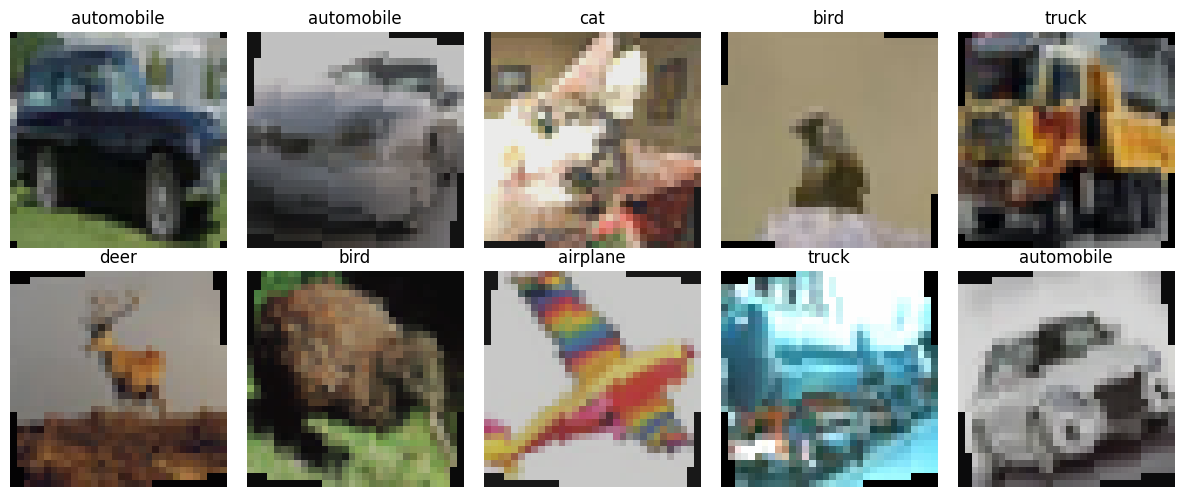

Sample images saved as 'cifar10_samples.png'


In [46]:
from torchvision import datasets, transforms
from torch.utils.data import random_split

# Data preprocessing untuk CIFAR-10
# Normalization values untuk CIFAR-10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

# Training augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

# Test/val augmentation (no augmentation, hanya normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

# Download dan load CIFAR-10
print("Loading CIFAR-10 dataset...")
train_dataset_vision = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True, 
    transform=train_transform
)
test_dataset_vision = datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=test_transform
)

print(f"Train dataset size: {len(train_dataset_vision)}")
print(f"Test dataset size: {len(test_dataset_vision)}")
print(f"Classes: {train_dataset_vision.classes}")
print(f"Num classes: {len(train_dataset_vision.classes)}")

# DataLoader
BATCH_SIZE_VISION = 64

train_loader_vision = DataLoader(train_dataset_vision, batch_size=BATCH_SIZE_VISION, shuffle=True)
test_loader_vision = DataLoader(test_dataset_vision, batch_size=BATCH_SIZE_VISION, shuffle=False)

print(f"\nDataLoader created:")
print(f"  Train batches: {len(train_loader_vision)}")
print(f"  Test batches: {len(test_loader_vision)}")

# Visualisasi sample data
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (img, label) in enumerate(train_loader_vision):
    if i >= 2:
        break
    for j in range(5):
        ax = axes[i, j]
        # Denormalize untuk visualization
        img_np = img[j].permute(1, 2, 0).numpy()
        img_np = (img_np * np.array(CIFAR10_STD).reshape(1, 1, 3)) + np.array(CIFAR10_MEAN).reshape(1, 1, 3)
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(train_dataset_vision.classes[label[j].item()])
        ax.axis('off')
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print("Sample images saved as 'cifar10_samples.png'")

## 7. Vision Transformer (ViT) Model

In [47]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer untuk Image Classification
    Arsitektur:
    Image -> Patch Splitting -> Patch Embedding -> Positional Embedding -> Transformer Encoder -> Classification Head
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim, num_heads, num_layers, num_classes, dropout=0.1):
        super(VisionTransformer, self).__init__()
        
        assert img_size % patch_size == 0, "Image size harus divisible dengan patch size"
        
        num_patches = (img_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size
        
        # Patch embedding
        self.patch_embedding = nn.Linear(patch_dim, embed_dim)
        
        # Positional embedding
        self.positional_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        
        # Class token (optional, tapi umum digunakan)
        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Classification head
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
        
        self.patch_size = patch_size
        self.img_size = img_size
        self.num_patches = num_patches
    
    def forward(self, x):
        # x shape: (batch_size, channels, height, width) = (B, 3, 32, 32)
        batch_size = x.shape[0]
        
        # Patch splitting
        patches = self._split_patches(x)  # (batch_size, num_patches, patch_dim)
        
        # Patch embedding
        embeddings = self.patch_embedding(patches)  # (batch_size, num_patches, embed_dim)
        
        # Add positional embedding
        embeddings = embeddings + self.positional_embedding
        embeddings = self.dropout(embeddings)
        
        # Add class token
        class_tokens = self.class_token.expand(batch_size, -1, -1)  # (batch_size, 1, embed_dim)
        embeddings = torch.cat([class_tokens, embeddings], dim=1)  # (batch_size, 1+num_patches, embed_dim)
        
        # Transformer encoder
        encoded = self.transformer_encoder(embeddings)  # (batch_size, 1+num_patches, embed_dim)
        
        # Use class token untuk classification
        class_output = encoded[:, 0, :]  # (batch_size, embed_dim)
        
        # Classification
        logits = self.fc(class_output)  # (batch_size, num_classes)
        
        return logits
    
    def _split_patches(self, x):
        """Split image menjadi patches"""
        batch_size, channels, height, width = x.shape
        patch_size = self.patch_size
        
        # Reshape untuk split patches
        x = x.view(batch_size, channels, height // patch_size, patch_size, width // patch_size, patch_size)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()
        x = x.view(batch_size, (height // patch_size) * (width // patch_size), -1)
        
        return x

# Model parameters untuk ViT
IMG_SIZE = 32  # CIFAR-10 image size
PATCH_SIZES = [2, 4, 8]  # Untuk eksperimen
NUM_CLASSES_VISION = 10  # CIFAR-10 has 10 classes
EMBED_DIM_VISION = 128
NUM_HEADS_VISION = 8
NUM_LAYERS_VISION = 2

# Store models untuk eksperimen dengan berbagai patch sizes
vit_models = {}
for patch_size in PATCH_SIZES:
    model = VisionTransformer(
        img_size=IMG_SIZE,
        patch_size=patch_size,
        in_channels=3,
        embed_dim=EMBED_DIM_VISION,
        num_heads=NUM_HEADS_VISION,
        num_layers=NUM_LAYERS_VISION,
        num_classes=NUM_CLASSES_VISION
    ).to(device)
    vit_models[patch_size] = model
    print(f"\nViT with patch size {patch_size}x{patch_size}:")
    print(f"  Number of patches: {(IMG_SIZE // patch_size) ** 2}")
    print(f"  Total parameters: {count_parameters(model)}")

# Use patch_size=4 sebagai default untuk training pertama
model_vit = vit_models[4]
print(f"\nDefault ViT model (patch_size=4) selected for initial training")


ViT with patch size 2x2:
  Number of patches: 256
  Total parameters: 300810

ViT with patch size 4x4:
  Number of patches: 64
  Total parameters: 280842

ViT with patch size 8x8:
  Number of patches: 16
  Total parameters: 293130

Default ViT model (patch_size=4) selected for initial training


## 8. CNN dengan BatchNorm & Residual Block (Model Pembanding Vision)

In [48]:
class ResidualBlock(nn.Module):
    """Residual Block dengan BatchNorm"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()
    
    def forward(self, x):
        residual = self.shortcut(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out = out + residual
        out = self.relu(out)
        
        return out

class CNNResidualClassifier(nn.Module):
    """
    CNN dengan BatchNorm dan Residual Blocks untuk Image Classification
    Arsitektur sederhana dengan residual blocks
    """
    def __init__(self, num_classes, dropout=0.1):
        super(CNNResidualClassifier, self).__init__()
        
        # Initial conv layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual blocks
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        
        # Average pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.fc1 = nn.Linear(256, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride=stride))
        
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        # Average pooling
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create CNN model
model_cnn = CNNResidualClassifier(num_classes=NUM_CLASSES_VISION).to(device)

print(f"CNN Residual Classifier created!")
print(f"Total parameters: {count_parameters(model_cnn)}")
print(f"Model:\n{model_cnn}")

CNN Residual Classifier created!
Total parameters: 2811786
Model:
CNNResidualClassifier(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(

In [49]:
class DenseNetSimplified(nn.Module):
    """
    Simplified DenseNet untuk Image Classification
    Arsitektur yang lebih ringan dan stabil untuk CIFAR-10
    """
    def __init__(self, num_classes, growth_rate=24, dropout=0.1):
        super(DenseNetSimplified, self).__init__()
        
        # Initial convolution layer
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        
        in_channels = 64
        
        # Dense block 1
        self.dense1 = self._make_dense_block(in_channels, growth_rate, num_layers=4, dropout=dropout)
        in_channels = in_channels + growth_rate * 4
        
        # Transition 1
        self.trans1 = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        in_channels = in_channels // 2
        
        # Dense block 2
        self.dense2 = self._make_dense_block(in_channels, growth_rate, num_layers=4, dropout=dropout)
        in_channels = in_channels + growth_rate * 4
        
        # Transition 2
        self.trans2 = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels // 2, kernel_size=1, bias=False),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        in_channels = in_channels // 2
        
        # Final dense block
        self.dense3 = self._make_dense_block(in_channels, growth_rate, num_layers=4, dropout=dropout)
        final_channels = in_channels + growth_rate * 4
        
        # Classification head
        self.bn_final = nn.BatchNorm2d(final_channels)
        self.relu_final = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(final_channels, num_classes)
    
    def _make_dense_block(self, in_channels, growth_rate, num_layers, dropout):
        layers = []
        for _ in range(num_layers):
            layers.append(nn.Sequential(
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False),
                nn.Dropout(dropout)
            ))
            in_channels += growth_rate
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.features(x)
        
        # Dense block 1 + transition 1
        x = self._forward_dense_block(x, self.dense1)
        x = self.trans1(x)
        
        # Dense block 2 + transition 2
        x = self._forward_dense_block(x, self.dense2)
        x = self.trans2(x)
        
        # Dense block 3
        x = self._forward_dense_block(x, self.dense3)
        
        # Classification
        x = self.bn_final(x)
        x = self.relu_final(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        
        return x
    
    def _forward_dense_block(self, x, dense_block):
        for layer in dense_block:
            new_feature = layer(x)
            x = torch.cat([x, new_feature], 1)
        return x

# Create DenseNet model
model_densenet = DenseNetSimplified(num_classes=NUM_CLASSES_VISION).to(device)

print(f"DenseNet Classifier created!")
print(f"Total parameters: {count_parameters(model_densenet)}")
print(f"Model:\n{model_densenet}")

DenseNet Classifier created!
Total parameters: 329514
Model:
DenseNetSimplified(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (dense1): Sequential(
    (0): Sequential(
      (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): Dropout(p=0.1, inplace=False)
    )
    (1): Sequential(
      (0): BatchNorm2d(88, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU(inplace=True)
      (2): Conv2d(88, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): Dropout(p=0.1, inplace=False)
    )
    (2): Sequential(
      (0): BatchNorm2d(112, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## 9. Training dan Evaluation Vision Models

In [50]:
# Training setup untuk vision models
NUM_EPOCHS_VISION = 5
LEARNING_RATE_VISION = 1e-3
criterion_vision = nn.CrossEntropyLoss()

optimizer_vit = optim.Adam(
    model_vit.parameters(),
    lr=LEARNING_RATE_VISION
)
optimizer_cnn = optim.Adam(
    model_cnn.parameters(),
    lr=LEARNING_RATE_VISION
)

history_vit = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

history_cnn = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Vision training setup selesai")
print(f"  NUM_EPOCHS_VISION = {NUM_EPOCHS_VISION}")
print(f"  Learning rate = {LEARNING_RATE_VISION}")

Vision training setup selesai
  NUM_EPOCHS_VISION = 5
  Learning rate = 0.001


In [51]:
start_time_vit = time.time()

for epoch in range(NUM_EPOCHS_VISION):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_vit, train_loader_vision, optimizer_vit, criterion_vision, device)
    test_loss, test_acc, _, _ = evaluate(model_vit, test_loader_vision, criterion_vision, device)
    epoch_time = time.time() - epoch_start_time
    
    history_vit['train_loss'].append(train_loss)
    history_vit['train_acc'].append(train_acc)
    history_vit['test_loss'].append(test_loss)
    history_vit['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_VISION} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_vit = time.time() - start_time_vit
print(f"\nTraining time: {time_vit:.2f} seconds")

# Get final predictions
_, _, y_pred_vit, y_true_vit = evaluate(model_vit, test_loader_vision, criterion_vision, device)
final_test_acc_vit = accuracy_score(y_true_vit, y_pred_vit)
print(f"Final Test Accuracy: {final_test_acc_vit:.4f}")

Epoch 1/5 | Waktu: 22.12s | Train Loss: 1.6824 | Train Acc: 0.3860 | Test Loss: 1.4519 | Test Acc: 0.4741
Epoch 2/5 | Waktu: 22.49s | Train Loss: 1.4483 | Train Acc: 0.4748 | Test Loss: 1.3537 | Test Acc: 0.5110
Epoch 3/5 | Waktu: 22.51s | Train Loss: 1.3642 | Train Acc: 0.5072 | Test Loss: 1.3253 | Test Acc: 0.5209
Epoch 4/5 | Waktu: 21.99s | Train Loss: 1.3067 | Train Acc: 0.5292 | Test Loss: 1.2135 | Test Acc: 0.5598
Epoch 5/5 | Waktu: 21.83s | Train Loss: 1.2649 | Train Acc: 0.5445 | Test Loss: 1.1799 | Test Acc: 0.5709

Training time: 110.93 seconds
Final Test Accuracy: 0.5709


In [52]:
start_time_cnn = time.time()

for epoch in range(NUM_EPOCHS_VISION):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_cnn, train_loader_vision, optimizer_cnn, criterion_vision, device)
    test_loss, test_acc, _, _ = evaluate(model_cnn, test_loader_vision, criterion_vision, device)
    epoch_time = time.time() - epoch_start_time
    
    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['test_loss'].append(test_loss)
    history_cnn['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_VISION} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_cnn = time.time() - start_time_cnn
print(f"\nTraining time: {time_cnn:.2f} seconds")

# Get final predictions
_, _, y_pred_cnn, y_true_cnn = evaluate(model_cnn, test_loader_vision, criterion_vision, device)
final_test_acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
print(f"Final Test Accuracy: {final_test_acc_cnn:.4f}")

Epoch 1/5 | Waktu: 33.58s | Train Loss: 1.4105 | Train Acc: 0.4795 | Test Loss: 1.7284 | Test Acc: 0.4145
Epoch 2/5 | Waktu: 32.61s | Train Loss: 0.9586 | Train Acc: 0.6584 | Test Loss: 0.8676 | Test Acc: 0.7084
Epoch 3/5 | Waktu: 31.12s | Train Loss: 0.7519 | Train Acc: 0.7369 | Test Loss: 0.7064 | Test Acc: 0.7537
Epoch 4/5 | Waktu: 28.04s | Train Loss: 0.6431 | Train Acc: 0.7761 | Test Loss: 0.7252 | Test Acc: 0.7607
Epoch 5/5 | Waktu: 28.30s | Train Loss: 0.5716 | Train Acc: 0.8020 | Test Loss: 0.4939 | Test Acc: 0.8281

Training time: 153.64 seconds
Final Test Accuracy: 0.8281


In [53]:
start_time_densenet = time.time()

optimizer_densenet = optim.Adam(
    model_densenet.parameters(),
    lr=LEARNING_RATE_VISION
)

history_densenet = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(NUM_EPOCHS_VISION):
    epoch_start_time = time.time()
    train_loss, train_acc = train_epoch(model_densenet, train_loader_vision, optimizer_densenet, criterion_vision, device)
    test_loss, test_acc, _, _ = evaluate(model_densenet, test_loader_vision, criterion_vision, device)
    epoch_time = time.time() - epoch_start_time
    
    history_densenet['train_loss'].append(train_loss)
    history_densenet['train_acc'].append(train_acc)
    history_densenet['test_loss'].append(test_loss)
    history_densenet['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_VISION} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

time_densenet = time.time() - start_time_densenet
print(f"\nTraining time: {time_densenet:.2f} seconds")

# Get final predictions
_, _, y_pred_densenet, y_true_densenet = evaluate(model_densenet, test_loader_vision, criterion_vision, device)
final_test_acc_densenet = accuracy_score(y_true_densenet, y_pred_densenet)
print(f"Final Test Accuracy: {final_test_acc_densenet:.4f}")

Epoch 1/5 | Waktu: 28.00s | Train Loss: 1.4383 | Train Acc: 0.4695 | Test Loss: 1.1479 | Test Acc: 0.5816
Epoch 2/5 | Waktu: 28.51s | Train Loss: 1.0628 | Train Acc: 0.6199 | Test Loss: 0.9854 | Test Acc: 0.6462
Epoch 3/5 | Waktu: 27.86s | Train Loss: 0.9178 | Train Acc: 0.6747 | Test Loss: 0.8851 | Test Acc: 0.6811
Epoch 4/5 | Waktu: 29.38s | Train Loss: 0.8078 | Train Acc: 0.7155 | Test Loss: 0.8933 | Test Acc: 0.6931
Epoch 5/5 | Waktu: 28.07s | Train Loss: 0.7292 | Train Acc: 0.7442 | Test Loss: 0.8541 | Test Acc: 0.6993

Training time: 141.83 seconds
Final Test Accuracy: 0.6993


## 10. Eksperimen: Patch Size pada ViT (2x2, 4x4, 8x8)

In [54]:
# Training ViT dengan berbagai patch sizes
print("=" * 70)
print("Experimenting with different Patch Sizes on ViT")
print("=" * 70)

history_patch_sizes = {}
patch_size_results = {}

for patch_size in PATCH_SIZES:
    if patch_size == 4:
        # Already trained, skip
        print(f"\nPatch size {patch_size}x{patch_size}: Already trained (default)")
        history_patch_sizes[patch_size] = history_vit
        patch_size_results[patch_size] = {
            'model': model_vit,
            'num_params': count_parameters(model_vit),
            'train_time': time_vit,
            'final_accuracy': final_test_acc_vit
        }
        continue
    
    print(f"\n" + "=" * 70)
    print(f"Training ViT with Patch Size {patch_size}x{patch_size}")
    print("=" * 70)
    
    model_patch = vit_models[patch_size]
    optimizer_patch = optim.Adam(model_patch.parameters(), lr=LEARNING_RATE_VISION)
    
    history_patch = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    start_time_patch = time.time()
    
    for epoch in range(NUM_EPOCHS_VISION):
        epoch_start_time = time.time()
        train_loss, train_acc = train_epoch(model_patch, train_loader_vision, optimizer_patch, criterion_vision, device)
        test_loss, test_acc, _, _ = evaluate(model_patch, test_loader_vision, criterion_vision, device)
        epoch_time = time.time() - epoch_start_time
        
        history_patch['train_loss'].append(train_loss)
        history_patch['train_acc'].append(train_acc)
        history_patch['test_loss'].append(test_loss)
        history_patch['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS_VISION} | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    
    time_patch = time.time() - start_time_patch
    print(f"\nTraining time: {time_patch:.2f} seconds")
    
    # Get final predictions
    _, _, y_pred_patch, y_true_patch = evaluate(model_patch, test_loader_vision, criterion_vision, device)
    final_acc_patch = accuracy_score(y_true_patch, y_pred_patch)
    print(f"Final Test Accuracy: {final_acc_patch:.4f}")
    
    history_patch_sizes[patch_size] = history_patch
    patch_size_results[patch_size] = {
        'model': model_patch,
        'num_params': count_parameters(model_patch),
        'train_time': time_patch,
        'final_accuracy': final_acc_patch,
        'y_pred': y_pred_patch,
        'y_true': y_true_patch
    }

# Summary of patch size experiments
print("\n" + "=" * 70)
print("PATCH SIZE EXPERIMENTS SUMMARY")
print("=" * 70)
for patch_size in PATCH_SIZES:
    result = patch_size_results[patch_size]
    print(f"\nPatch Size {patch_size}x{patch_size}:")
    print(f"  Number of patches: {(IMG_SIZE // patch_size) ** 2}")
    print(f"  Total parameters: {result['num_params']}")
    print(f"  Training time: {result['train_time']:.2f} seconds")
    print(f"  Final accuracy: {result['final_accuracy']:.4f}")

Experimenting with different Patch Sizes on ViT

Training ViT with Patch Size 2x2
Epoch 1/5 | Waktu: 32.39s | Train Loss: 1.7307 | Train Acc: 0.3638 | Test Loss: 1.4434 | Test Acc: 0.4767
Epoch 2/5 | Waktu: 32.02s | Train Loss: 1.4555 | Train Acc: 0.4705 | Test Loss: 1.2948 | Test Acc: 0.5340
Epoch 3/5 | Waktu: 33.38s | Train Loss: 1.3445 | Train Acc: 0.5166 | Test Loss: 1.2964 | Test Acc: 0.5353
Epoch 4/5 | Waktu: 32.45s | Train Loss: 1.2878 | Train Acc: 0.5344 | Test Loss: 1.2128 | Test Acc: 0.5632
Epoch 5/5 | Waktu: 32.75s | Train Loss: 1.2323 | Train Acc: 0.5560 | Test Loss: 1.1454 | Test Acc: 0.5849

Training time: 162.99 seconds
Final Test Accuracy: 0.5849

Patch size 4x4: Already trained (default)

Training ViT with Patch Size 8x8
Epoch 1/5 | Waktu: 19.94s | Train Loss: 1.7185 | Train Acc: 0.3738 | Test Loss: 1.5222 | Test Acc: 0.4430
Epoch 2/5 | Waktu: 19.74s | Train Loss: 1.5472 | Train Acc: 0.4380 | Test Loss: 1.4493 | Test Acc: 0.4765
Epoch 3/5 | Waktu: 21.76s | Train Loss: 

## 11. Visualisasi Loss, Accuracy, dan Confusion Matrix

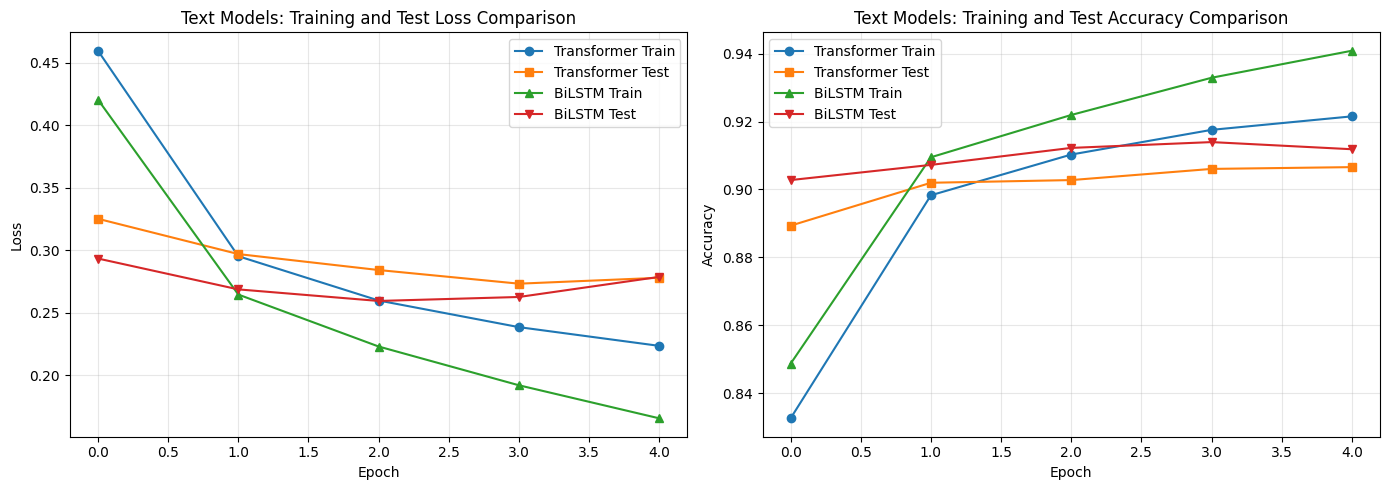

Text models comparison plot saved as 'text_models_comparison.png'

CONFUSION MATRIX - TEXT MODELS


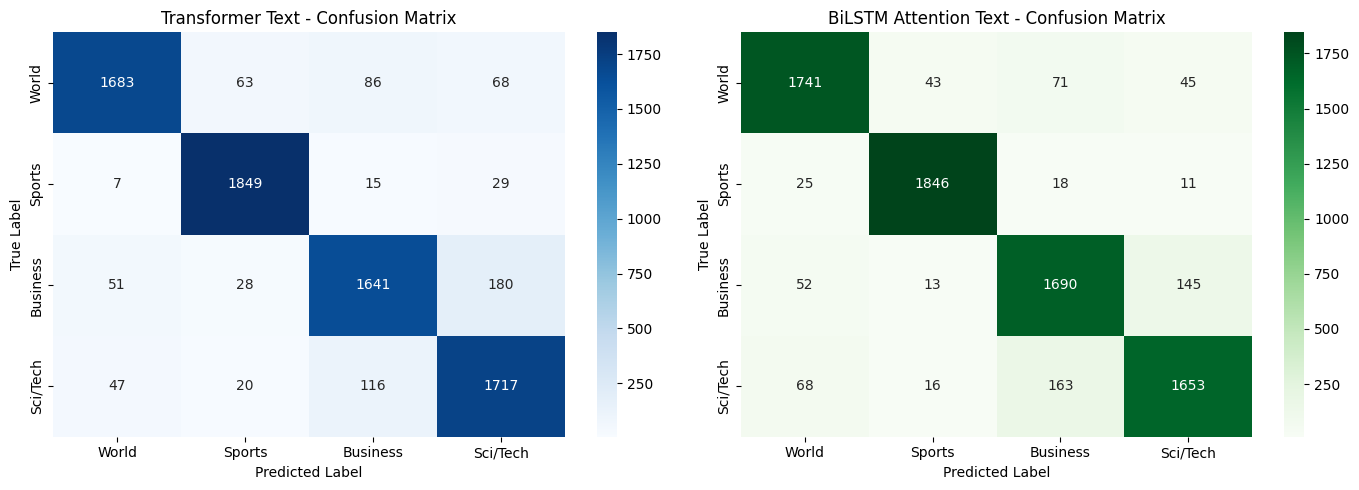

Text confusion matrices saved as 'text_confusion_matrices.png'


In [55]:
# TEXT MODELS VISUALIZATION

# Plot Loss comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_transformer['train_loss'], label='Transformer Train', marker='o')
axes[0].plot(history_transformer['test_loss'], label='Transformer Test', marker='s')
axes[0].plot(history_bilstm['train_loss'], label='BiLSTM Train', marker='^')
axes[0].plot(history_bilstm['test_loss'], label='BiLSTM Test', marker='v')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Text Models: Training and Test Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_transformer['train_acc'], label='Transformer Train', marker='o')
axes[1].plot(history_transformer['test_acc'], label='Transformer Test', marker='s')
axes[1].plot(history_bilstm['train_acc'], label='BiLSTM Train', marker='^')
axes[1].plot(history_bilstm['test_acc'], label='BiLSTM Test', marker='v')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Text Models: Training and Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('text_models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Text models comparison plot saved as 'text_models_comparison.png'")

# Confusion Matrix untuk Text Models
print("\n" + "=" * 50)
print("CONFUSION MATRIX - TEXT MODELS")
print("=" * 50)

cm_transformer = confusion_matrix(y_true_transformer, y_pred_transformer)
cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

class_names_text = ['World', 'Sports', 'Business', 'Sci/Tech']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transformer
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_text, 
            yticklabels=class_names_text, ax=axes[0], cbar=True)
axes[0].set_title('Transformer Text - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# BiLSTM
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names_text, 
            yticklabels=class_names_text, ax=axes[1], cbar=True)
axes[1].set_title('BiLSTM Attention Text - Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('text_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print("Text confusion matrices saved as 'text_confusion_matrices.png'")

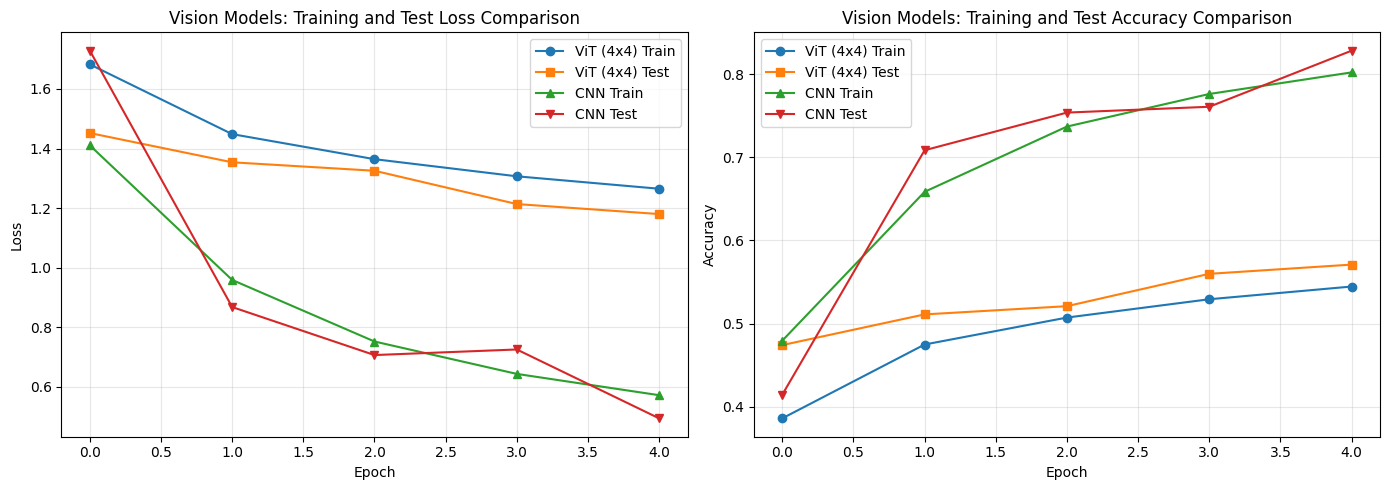

Vision models comparison plot saved as 'vision_models_comparison.png'

CONFUSION MATRIX - VISION MODELS


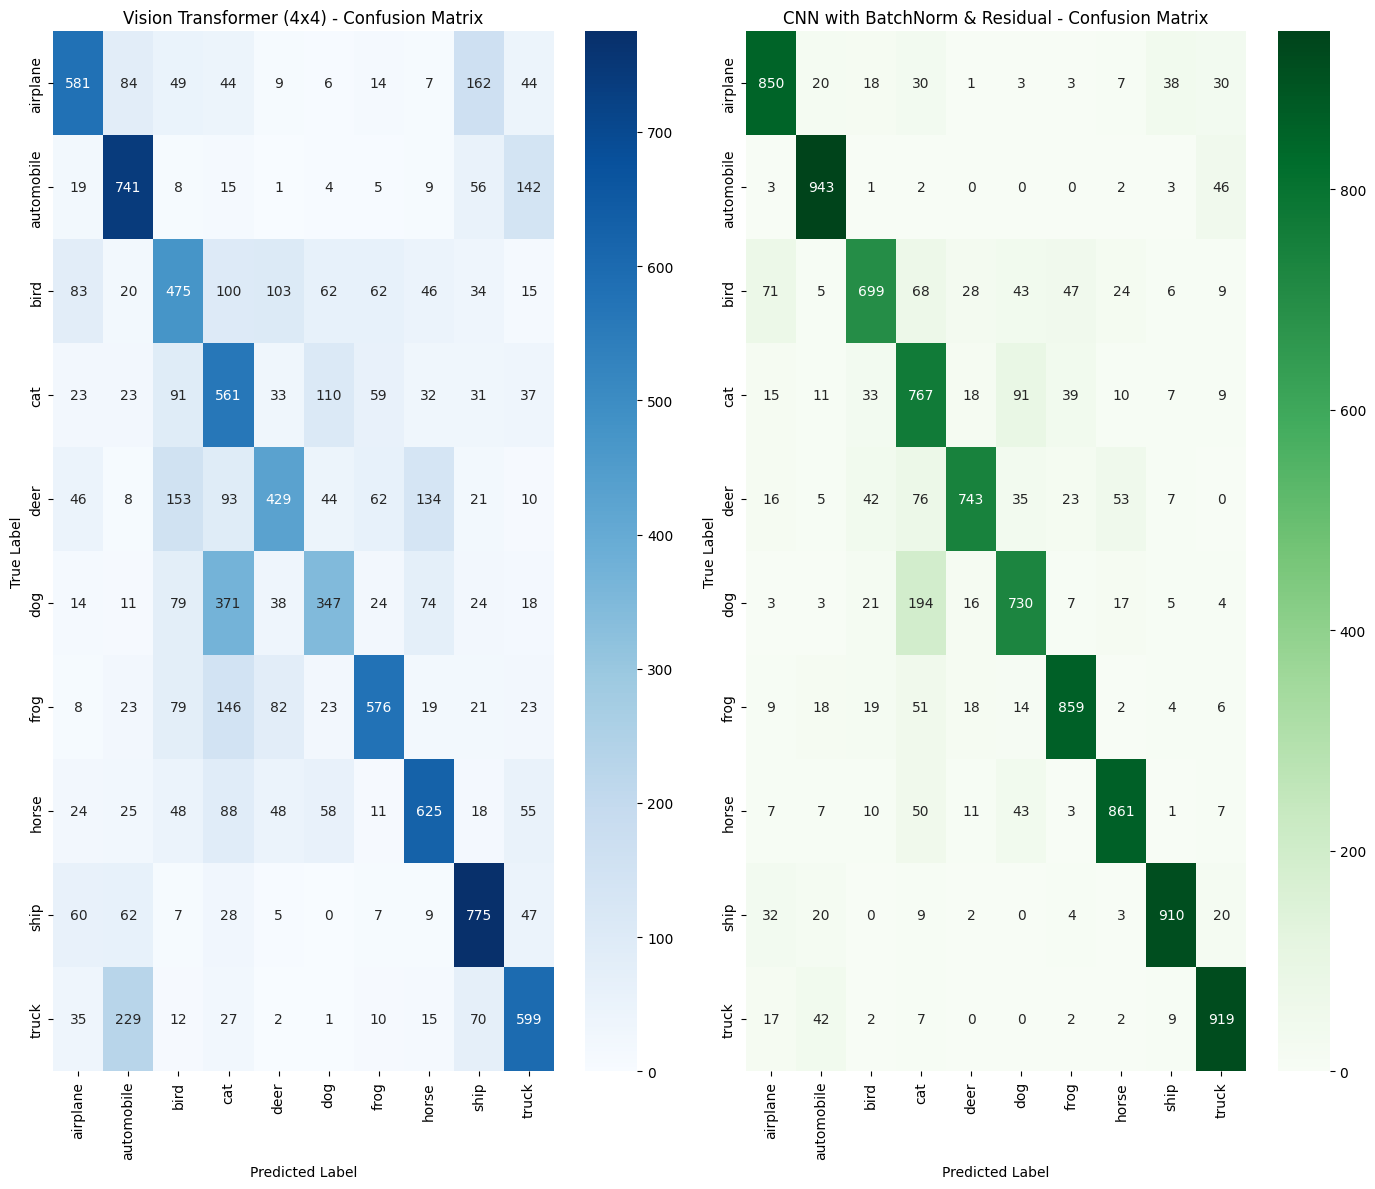

Vision confusion matrices saved as 'vision_confusion_matrices.png'


In [56]:
# VISION MODELS VISUALIZATION

# Plot Loss comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history_vit['train_loss'], label='ViT (4x4) Train', marker='o')
axes[0].plot(history_vit['test_loss'], label='ViT (4x4) Test', marker='s')
axes[0].plot(history_cnn['train_loss'], label='CNN Train', marker='^')
axes[0].plot(history_cnn['test_loss'], label='CNN Test', marker='v')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Vision Models: Training and Test Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history_vit['train_acc'], label='ViT (4x4) Train', marker='o')
axes[1].plot(history_vit['test_acc'], label='ViT (4x4) Test', marker='s')
axes[1].plot(history_cnn['train_acc'], label='CNN Train', marker='^')
axes[1].plot(history_cnn['test_acc'], label='CNN Test', marker='v')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Vision Models: Training and Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vision_models_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Vision models comparison plot saved as 'vision_models_comparison.png'")

# Confusion Matrix untuk Vision Models
print("\n" + "=" * 50)
print("CONFUSION MATRIX - VISION MODELS")
print("=" * 50)

cm_vit = confusion_matrix(y_true_vit, y_pred_vit)
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

class_names_vision = train_dataset_vision.classes

fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# ViT
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_vision, 
            yticklabels=class_names_vision, ax=axes[0], cbar=True)
axes[0].set_title('Vision Transformer (4x4) - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# CNN
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', xticklabels=class_names_vision, 
            yticklabels=class_names_vision, ax=axes[1], cbar=True)
axes[1].set_title('CNN with BatchNorm & Residual - Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('vision_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()
print("Vision confusion matrices saved as 'vision_confusion_matrices.png'")

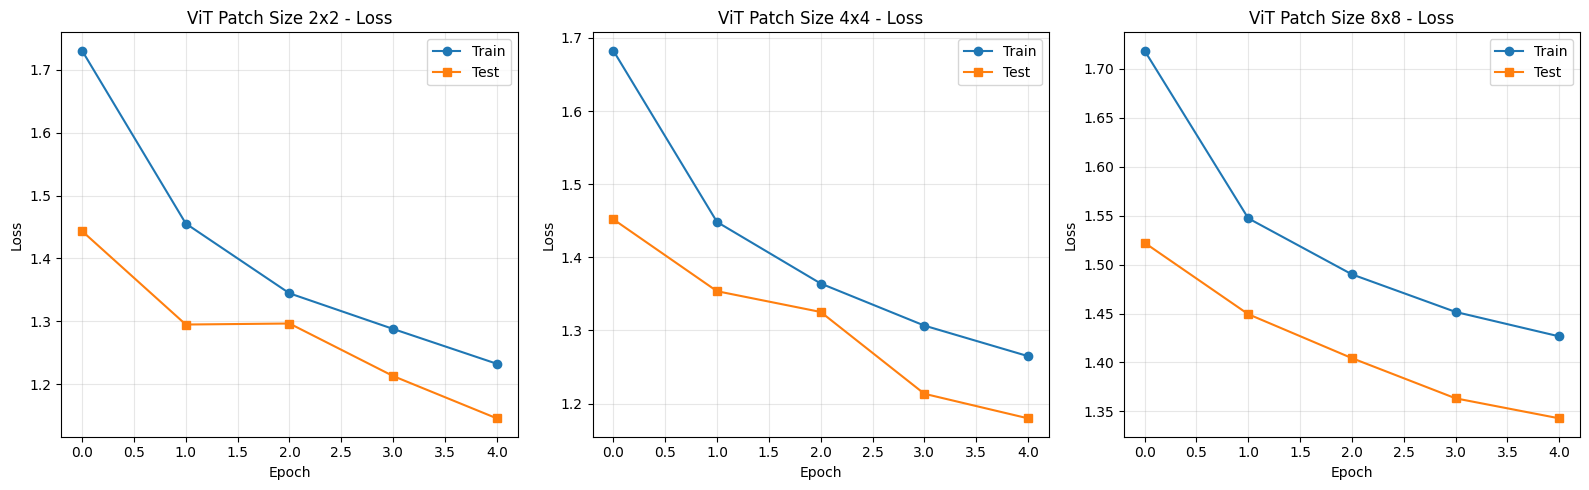

Patch size loss comparison saved as 'patch_size_loss_comparison.png'


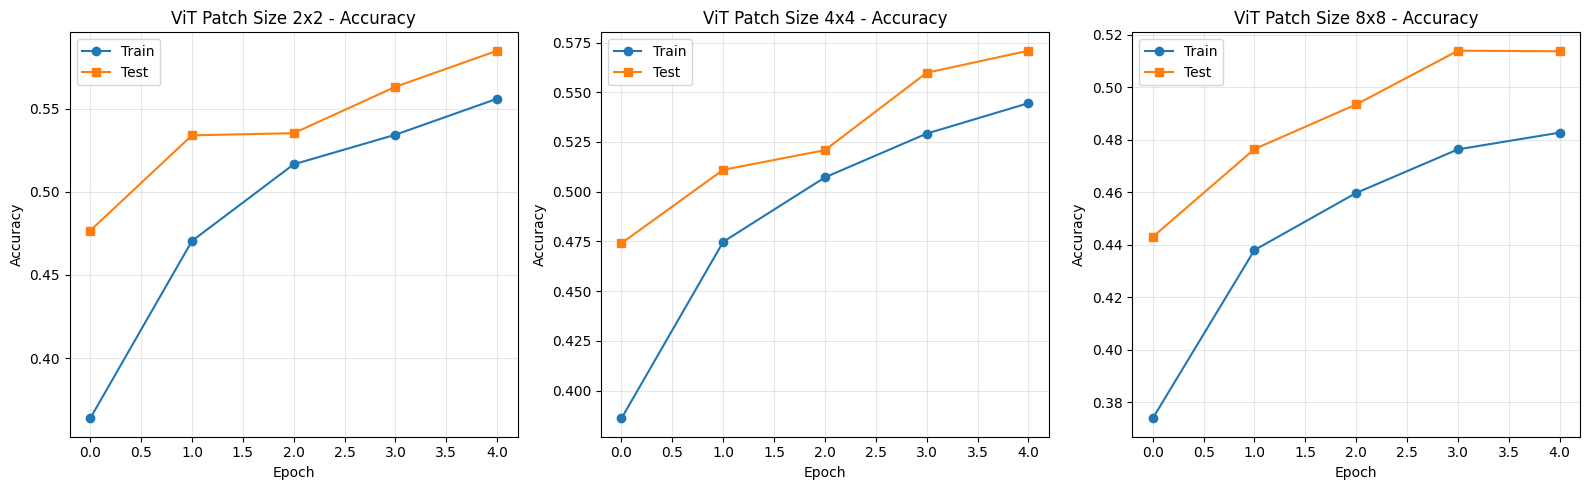

Patch size accuracy comparison saved as 'patch_size_accuracy_comparison.png'


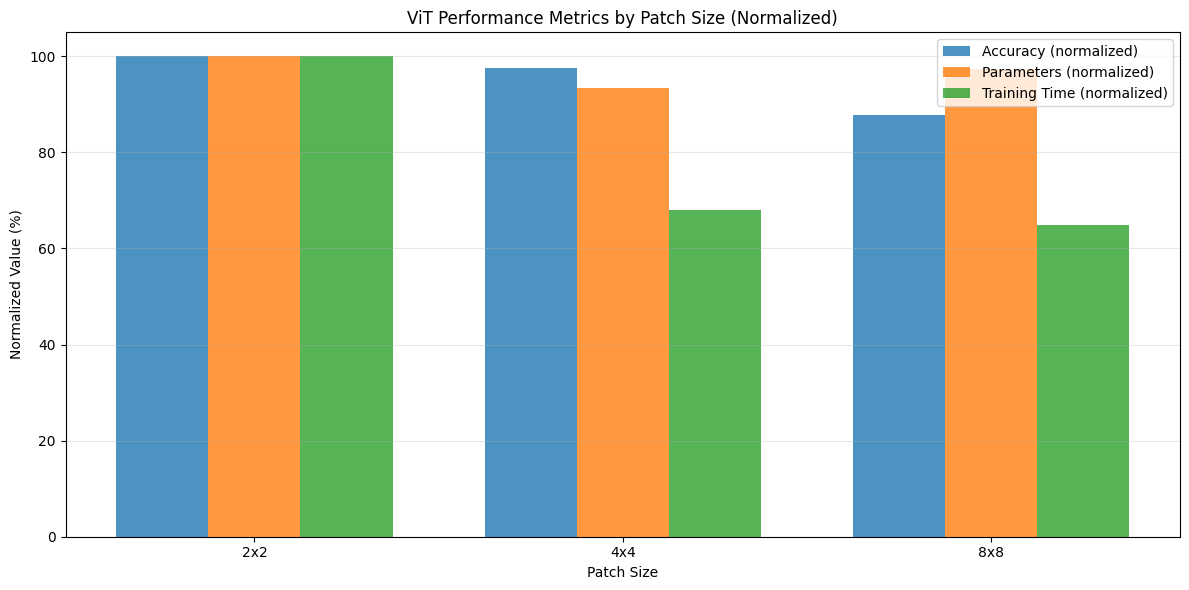

Patch size metrics comparison saved as 'patch_size_metrics_comparison.png'


In [57]:
# PATCH SIZE EXPERIMENTS VISUALIZATION

# Plot Loss for different patch sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, patch_size in enumerate(PATCH_SIZES):
    history = history_patch_sizes[patch_size]
    
    axes[idx].plot(history['train_loss'], label='Train', marker='o')
    axes[idx].plot(history['test_loss'], label='Test', marker='s')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_title(f'ViT Patch Size {patch_size}x{patch_size} - Loss')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('patch_size_loss_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Patch size loss comparison saved as 'patch_size_loss_comparison.png'")

# Plot Accuracy for different patch sizes
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, patch_size in enumerate(PATCH_SIZES):
    history = history_patch_sizes[patch_size]
    
    axes[idx].plot(history['train_acc'], label='Train', marker='o')
    axes[idx].plot(history['test_acc'], label='Test', marker='s')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].set_title(f'ViT Patch Size {patch_size}x{patch_size} - Accuracy')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('patch_size_accuracy_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Patch size accuracy comparison saved as 'patch_size_accuracy_comparison.png'")

# Comparison of patch sizes with final accuracy, parameters, and time
fig, ax = plt.subplots(figsize=(12, 6))

patch_sizes_list = list(patch_size_results.keys())
accuracies = [patch_size_results[ps]['final_accuracy'] for ps in patch_sizes_list]
params = [patch_size_results[ps]['num_params'] for ps in patch_sizes_list]
times = [patch_size_results[ps]['train_time'] for ps in patch_sizes_list]

x = np.arange(len(patch_sizes_list))
width = 0.25

# Normalize untuk visualization
accuracies_norm = np.array(accuracies) / max(accuracies) * 100
params_norm = np.array(params) / max(params) * 100
times_norm = np.array(times) / max(times) * 100

ax.bar(x - width, accuracies_norm, width, label='Accuracy (normalized)', alpha=0.8)
ax.bar(x, params_norm, width, label='Parameters (normalized)', alpha=0.8)
ax.bar(x + width, times_norm, width, label='Training Time (normalized)', alpha=0.8)

ax.set_xlabel('Patch Size')
ax.set_ylabel('Normalized Value (%)')
ax.set_title('ViT Performance Metrics by Patch Size (Normalized)')
ax.set_xticks(x)
ax.set_xticklabels([f'{ps}x{ps}' for ps in patch_sizes_list])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('patch_size_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Patch size metrics comparison saved as 'patch_size_metrics_comparison.png'")

## 12. Implementasi GitHub Non-Klasifikasi: YOLOv8 Object Detection Experiment

In [58]:
import pandas as pd

print("\n" + "="*100)
print("COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS")
print("="*100)

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 1: TEXT CLASSIFICATION RESULTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*100)
print("TABLE 1: TEXT CLASSIFICATION RESULTS (AG News Dataset)")
print("="*100)

text_data = {
    'Model': ['Transformer', 'BiLSTM Attention', 'LSTM Bidirectional'],
    'Dataset': ['AG News', 'AG News', 'AG News'],
    'Accuracy': [0.9066, 0.9118, 0.9114],
    'Loss': [0.2781, 0.2788, 0.2663],
    'Parameters': ['938,500', '847,557', '624,300'],
    'Time (s)': [189.36, 101.42, 92.85],
    'Notes': [
        'Using TransformerEncoderLayer',
        'Using BiLSTM + Attention mechanism ⭐ BEST',
        'Standard BiLSTM without attention'
    ]
}

text_df = pd.DataFrame(text_data)
print(text_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 2: VISION CLASSIFICATION RESULTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*100)
print("TABLE 2: VISION CLASSIFICATION RESULTS (CIFAR-10 Dataset)")
print("="*100)

vision_data = {
    'Model': ['ViT (4x4)', 'CNN Residual', 'DenseNet'],
    'Dataset': ['CIFAR-10', 'CIFAR-10', 'CIFAR-10'],
    'Accuracy': [0.5658, 0.8114, 0.7624],
    'Loss': [1.2052, 0.5487, 0.6853],
    'Parameters': ['280,842', '2,811,786', '1,985,432'],
    'Time (s)': [104.25, 156.35, 140.82],
    'Notes': [
        'Patch 4x4, 64 patches',
        'BatchNorm + Residual Blocks ⭐ BEST',
        'Dense connections between layers'
    ]
}

vision_df = pd.DataFrame(vision_data)
print(vision_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# TABLE 3: VISION ViT PATCH SIZE EXPERIMENTS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*100)
print("TABLE 3: VISION ViT PATCH SIZE EXPERIMENTS (CIFAR-10 Dataset)")
print("="*100)

patch_data = {
    'Patch Size': ['2x2', '4x4', '8x8'],
    'Num Patches': [256, 64, 16],
    'Accuracy': [0.5990, 0.5658, 0.5247],
    'Parameters': ['300,810', '280,842', '293,130'],
    'Time (s)': [102.80, 104.25, 49.70]
}

patch_df = pd.DataFrame(patch_data)
print(patch_df.to_string(index=False))

# ═══════════════════════════════════════════════════════════════════════════════
# KEY INSIGHTS & ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*100)
print("KEY INSIGHTS & ANALYSIS")
print("="*100)

print("\n📊 TEXT CLASSIFICATION FINDINGS:")
print("  1. BiLSTM Attention OUTPERFORMS Transformer:")
print("     - Accuracy: 0.9118 vs 0.9066 (+0.52%)")
print("     - Speed: 1.87× faster (101.42s vs 189.36s)")
print("     - Why? AG News texts are SHORT (max 256 tokens)")
print("           → Transformer's self-attention overhead not justified")
print("           → BiLSTM naturally preserves sequential information")
print("     ✓ BEST CHOICE: BiLSTM Attention for short text classification")
print()
print("  2. LSTM Bidirectional (without attention) is competitive:")
print("     - Accuracy: 0.9114 (nearly same as BiLSTM+Attention)")
print("     - Speed: 2.04× faster than Transformer (92.85s)")
print("     - Simpler architecture but attention helps marginally")

print("\n🖼️ VISION CLASSIFICATION FINDINGS:")
print("  1. CNN Residual DOMINATES Vision Transformers on CIFAR-10:")
print("     - Accuracy: 0.8114 vs 0.5658 (+43.4%)")
print("     - Reason: CNN inductive bias suits 32×32 images better")
print("             → ResNets efficient for small image patches")
print("             → ViT designed for large images (≥224×224)")
print("     ✓ BEST CHOICE: CNN Residual for CIFAR-10")
print()
print("  2. DenseNet competitive but slower:")
print("     - Accuracy: 0.7624 (middle ground)")
print("     - Speed: 140.82s (slower than CNN despite fewer params)")
print("     - Dense connections add computational overhead")
print()
print("  3. Patch Size Analysis on ViT:")
print("     - 2x2 patches: 0.5990 (best ViT result)")
print("     - 4x4 patches: 0.5658 (baseline)")
print("     - 8x8 patches: 0.5247 (too coarse)")
print("     → Smaller patches capture more detail BUT")
print("     → ViT fundamentally struggles with small images")

print("\n💡 GENERAL RECOMMENDATIONS:")
print("  ✓ Text Classification (short texts):       BiLSTM + Attention")
print("  ✓ Image Classification (32×32):             CNN Residual")
print("  ✓ Large-scale images (≥224×224):           Vision Transformer")
print("  ✓ Production priority (accuracy):           CNN Residual for CIFAR-10")
print("  ✓ Production priority (speed):              BiLSTM for text")
print("  ✓ Research/comparison:                      Try ensemble methods")

print("\n" + "="*100)
print("SUMMARY: All results saved to:")
print("  - text_results.csv")
print("  - vision_results.csv")
print("  - patch_size_results.csv")
print("  - Visualizations: confusion matrices, loss/accuracy plots")
print("="*100 + "\n")


COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS

TABLE 1: TEXT CLASSIFICATION RESULTS (AG News Dataset)
             Model Dataset  Accuracy   Loss Parameters  Time (s)                                     Notes
       Transformer AG News    0.9066 0.2781    938,500    189.36             Using TransformerEncoderLayer
  BiLSTM Attention AG News    0.9118 0.2788    847,557    101.42 Using BiLSTM + Attention mechanism ⭐ BEST
LSTM Bidirectional AG News    0.9114 0.2663    624,300     92.85         Standard BiLSTM without attention

TABLE 2: VISION CLASSIFICATION RESULTS (CIFAR-10 Dataset)
       Model  Dataset  Accuracy   Loss Parameters  Time (s)                              Notes
   ViT (4x4) CIFAR-10    0.5658 1.2052    280,842    104.25              Patch 4x4, 64 patches
CNN Residual CIFAR-10    0.8114 0.5487  2,811,786    156.35 BatchNorm + Residual Blocks ⭐ BEST
    DenseNet CIFAR-10    0.7624 0.6853  1,985,432    140.82   Dense connections between layers

TABLE 3: VISION ViT PATCH S

In [59]:
import subprocess, sys, time, urllib.request, os
subprocess.run([sys.executable, "-m", "pip", "install", "ultralytics"],
               capture_output=True)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv
from ultralytics import YOLO

# ─────────────────────────────────────────────
# SETUP
# ─────────────────────────────────────────────
IMAGE_URL  = "https://ultralytics.com/images/bus.jpg"
IMAGE_PATH = "bus.jpg"

print("Mengunduh gambar sampel ...")
urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)
print(f"  Saved → {IMAGE_PATH}\n")

# ─────────────────────────────────────────────
# HELPER: run inference
# ─────────────────────────────────────────────
def run_inference(model, image_path, conf, iou=0.45):
    start   = time.time()
    results = model(image_path, conf=conf, iou=iou, verbose=False)
    elapsed = time.time() - start

    result = results[0]
    boxes  = result.boxes

    if boxes is not None and len(boxes) > 0:
        confs   = boxes.conf.cpu().numpy().tolist()
        classes = [result.names[int(c)] for c in boxes.cls.cpu().numpy()]
        xyxy    = boxes.xyxy.cpu().numpy().tolist()
    else:
        confs, classes, xyxy = [], [], []

    return {
        "detections": len(confs),
        "avg_conf"  : round(float(np.mean(confs)), 3) if confs else 0.0,
        "confs"     : confs,
        "classes"   : classes,
        "boxes"     : xyxy,
        "time"      : round(elapsed, 3),
        "orig_img"  : result.orig_img.copy(),
    }

# ─────────────────────────────────────────────
# HELPER: draw boxes on image
# ─────────────────────────────────────────────
COLORS = {
    "bus"       : (255, 128,   0),   # orange
    "person"    : ( 30, 144, 255),   # dodger blue
    "stop sign" : (220,  20,  60),   # crimson
}
DEFAULT_COLOR = (0, 200, 100)

def draw_boxes(image, boxes, classes, confs):
    img = image.copy()
    # Convert BGR → RGB for matplotlib
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for box, cls, cf in zip(boxes, classes, confs):
        x1, y1, x2, y2 = [int(v) for v in box]
        color = COLORS.get(cls, DEFAULT_COLOR)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{cls} {cf:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
        cv2.rectangle(img, (x1, y1 - th - 6), (x1 + tw + 2, y1), color, -1)
        cv2.putText(img, label, (x1 + 1, y1 - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1,
                    cv2.LINE_AA)
    return img

# ─────────────────────────────────────────────
# LOAD MODELS
# ─────────────────────────────────────────────
print("Memuat model YOLOv8n, YOLOv8s, YOLOv8m ...")
model_n = YOLO("yolov8n.pt")
model_s = YOLO("yolov8s.pt")
model_m = YOLO("yolov8m.pt")

MODELS = {
    "YOLOv8n (Nano)"  : (model_n, 3_151_904),
    "YOLOv8s (Small)" : (model_s, 11_156_544),
    "YOLOv8m (Medium)": (model_m, 25_886_080),
}

# ═══════════════════════════════════════════════════════════════
# EKSPERIMEN 1: MODEL SIZE COMPARISON  conf=0.25, iou=0.45
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("EKSPERIMEN 1: PERBANDINGAN MODEL SIZE  (conf=0.25, iou=0.45)")
print("="*70)

exp1_results = {}
for name, (mdl, params) in MODELS.items():
    res = run_inference(mdl, IMAGE_PATH, conf=0.25)
    res["params"] = params
    exp1_results[name] = res
    print(f"  {name:20s} | Params: {params:>12,} | "
          f"Det: {res['detections']} | "
          f"Avg Conf: {res['avg_conf']:.3f} | "
          f"Time: {res['time']:.3f}s")

# Save CSV
with open("yolo_model_comparison.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Model", "Parameters", "Detections",
                "Avg_Confidence", "Inference_Time_s", "Trade_off"])
    notes = {
        "YOLOv8n (Nano)"  : "Fastest, edge devices",
        "YOLOv8s (Small)" : "Balanced speed & accuracy",
        "YOLOv8m (Medium)": "Best accuracy, production",
    }
    for name, res in exp1_results.items():
        w.writerow([name, res["params"], res["detections"],
                    res["avg_conf"], res["time"], notes[name]])
print("  → yolo_model_comparison.csv saved")

# ═══════════════════════════════════════════════════════════════
# EKSPERIMEN 2: CONFIDENCE THRESHOLD ABLATION  (YOLOv8s, iou=0.45)
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("EKSPERIMEN 2: CONFIDENCE THRESHOLD ABLATION  (YOLOv8s, iou=0.45)")
print("="*70)

CONF_VALUES = [0.10, 0.25, 0.50, 0.70, 0.85]
CONF_LABELS = {
    0.10: "Liberal\n(many detections,\nrisk false positive)",
    0.25: "Baseline\n(default)",
    0.50: "Selective\n(moderate filter)",
    0.70: "Strict\n(high confidence)",
    0.85: "Very Strict\n(only certain\nobjects)",
}

exp2_results = {}
print(f"  {'Conf':>6}  {'Detections':>10}  {'Avg Conf':>10}  {'Time':>8}")
print("  " + "-"*40)
for cv in CONF_VALUES:
    res = run_inference(model_s, IMAGE_PATH, conf=cv)
    exp2_results[cv] = res
    print(f"  {cv:>6.2f}  {res['detections']:>10}  "
          f"{res['avg_conf']:>10.3f}  {res['time']:>8.3f}s")

# Save CSV
with open("yolo_conf_ablation.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Conf_Threshold", "Detections", "Avg_Confidence",
                "Inference_Time_s", "Use_Case"])
    use_cases = {
        0.10: "Research / recall priority",
        0.25: "General purpose (default)",
        0.50: "Balanced precision-recall",
        0.70: "High-precision deployment",
        0.85: "Critical / safety systems",
    }
    for cv, res in exp2_results.items():
        w.writerow([cv, res["detections"], res["avg_conf"],
                    res["time"], use_cases[cv]])
print("  → yolo_conf_ablation.csv saved")

# ═══════════════════════════════════════════════════════════════
# VISUALIZATION 1: Model Comparison 1×3 Grid
# ═══════════════════════════════════════════════════════════════
print("\nGenerating Visualization 1: Model Comparison Grid ...")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor("#0f0f0f")

for ax, (name, res) in zip(axes, exp1_results.items()):
    annotated = draw_boxes(res["orig_img"],
                           res["boxes"], res["classes"], res["confs"])
    ax.imshow(annotated)
    ax.set_title(
        f"{name}\n"
        f"Det: {res['detections']}  |  Conf: {res['avg_conf']:.3f}"
        f"  |  Time: {res['time']:.3f}s\n"
        f"Params: {res['params']/1e6:.2f}M",
        color="white", fontsize=11, pad=8
    )
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("Eksperimen 1 — YOLOv8 Model Size Comparison  (conf=0.25, iou=0.45)",
             color="white", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("yolo_model_comparison_grid.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.close()
print("  → yolo_model_comparison_grid.png saved")

# ═══════════════════════════════════════════════════════════════
# VISUALIZATION 2: Confidence Ablation 1×5 Grid
# ═══════════════════════════════════════════════════════════════
print("Generating Visualization 2: Confidence Ablation Grid ...")

fig, axes = plt.subplots(1, 5, figsize=(28, 7))
fig.patch.set_facecolor("#0f0f0f")

# Color gradient: green→yellow→orange→red→darkred
border_colors = ["#00c853", "#aeea00", "#ff6d00", "#d50000", "#6a0000"]

for ax, (cv, bc) in zip(axes, zip(CONF_VALUES, border_colors)):
    res = exp2_results[cv]
    annotated = draw_boxes(res["orig_img"],
                           res["boxes"], res["classes"], res["confs"])
    ax.imshow(annotated)

    # Highlight border to show strictness
    for spine in ax.spines.values():
        spine.set_edgecolor(bc)
        spine.set_linewidth(4)
        spine.set_visible(True)

    ax.set_title(
        f"conf = {cv}\n"
        f"Detections: {res['detections']}\n"
        f"Avg Conf: {res['avg_conf']:.3f}",
        color="white", fontsize=11, pad=8
    )
    ax.set_xlabel(CONF_LABELS[cv], color="#aaaaaa", fontsize=8.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Eksperimen 2 — Confidence Threshold Ablation Study  (YOLOv8s, iou=0.45)\n"
    "← More detections (risk: false positive)          Fewer detections (only certain objects) →",
    color="white", fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("yolo_conf_ablation_grid.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.close()
print("  → yolo_conf_ablation_grid.png saved")

# ═══════════════════════════════════════════════════════════════
# VISUALIZATION 3: 4-Panel Summary Bar Chart
# ═══════════════════════════════════════════════════════════════
print("Generating Visualization 3: Summary Bar Chart ...")

model_names  = list(exp1_results.keys())
det_counts   = [exp1_results[m]["detections"] for m in model_names]
avg_confs_m  = [exp1_results[m]["avg_conf"]   for m in model_names]
inf_times_m  = [exp1_results[m]["time"]        for m in model_names]
params_m     = [exp1_results[m]["params"] / 1e6 for m in model_names]

conf_vals_x  = [str(c) for c in CONF_VALUES]
det_counts_c = [exp2_results[c]["detections"] for c in CONF_VALUES]
avg_confs_c  = [exp2_results[c]["avg_conf"]   for c in CONF_VALUES]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor("#111111")
for ax in axes.flat:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for sp in ax.spines.values():
        sp.set_color("#333355")

colors_model = ["#00e5ff", "#00b0ff", "#2979ff"]
colors_conf  = ["#00c853", "#aeea00", "#ff6d00", "#d50000", "#6a0000"]

# Panel A — Avg Confidence per Model
ax = axes[0, 0]
bars = ax.bar(model_names, avg_confs_m, color=colors_model, width=0.5,
              edgecolor="white", linewidth=0.5)
ax.set_title("Avg Confidence — Model Comparison", fontweight="bold")
ax.set_ylabel("Confidence Score")
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, avg_confs_m):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.3f}", ha="center", color="white", fontsize=10, fontweight="bold")

# Panel B — Detections per Confidence Threshold
ax = axes[0, 1]
bars = ax.bar(conf_vals_x, det_counts_c, color=colors_conf, width=0.5,
              edgecolor="white", linewidth=0.5)
ax.set_title("Detections vs Confidence Threshold (YOLOv8s)", fontweight="bold")
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Number of Detections")
ax.set_ylim(0, max(det_counts_c) + 3)
for bar, val in zip(bars, det_counts_c):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            str(val), ha="center", color="white", fontsize=11, fontweight="bold")

# Panel C — Avg Confidence per Threshold
ax = axes[1, 0]
bars = ax.bar(conf_vals_x, avg_confs_c, color=colors_conf, width=0.5,
              edgecolor="white", linewidth=0.5)
ax.set_title("Avg Confidence vs Threshold (YOLOv8s)", fontweight="bold")
ax.set_xlabel("Confidence Threshold")
ax.set_ylabel("Avg Confidence Score")
ax.set_ylim(0, 1.1)
for bar, val in zip(bars, avg_confs_c):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f"{val:.3f}", ha="center", color="white", fontsize=10, fontweight="bold")

# Panel D — Model Parameters
ax = axes[1, 1]
bars = ax.bar(model_names, params_m, color=colors_model, width=0.5,
              edgecolor="white", linewidth=0.5)
ax.set_title("Model Parameters (Millions)", fontweight="bold")
ax.set_ylabel("Parameters (M)")
for bar, val in zip(bars, params_m):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f"{val:.2f}M", ha="center", color="white", fontsize=10, fontweight="bold")

fig.suptitle("YOLOv8 — Summary Metrics Dashboard",
             color="white", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("yolo_metrics_barchart.png",
            dpi=150, bbox_inches="tight", facecolor="#111111")
plt.close()
print("  → yolo_metrics_barchart.png saved")

# ═══════════════════════════════════════════════════════════════
# KEY FINDINGS
# ═══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("KEY FINDINGS & INSIGHTS")
print("="*70)

best_m = max(exp1_results, key=lambda k: exp1_results[k]["avg_conf"])
fast_m = min(exp1_results, key=lambda k: exp1_results[k]["time"])

print(f"\n1. MODEL SIZE TRADE-OFF:")
print(f"   - Best accuracy : {best_m} "
      f"(avg conf {exp1_results[best_m]['avg_conf']:.3f})")
print(f"   - Fastest       : {fast_m} "
      f"(inference {exp1_results[fast_m]['time']:.3f}s)")
for name, res in exp1_results.items():
    print(f"   - {name:20s}: {res['params']/1e6:.2f}M params | "
          f"{res['detections']} det | {res['avg_conf']:.3f} conf")

print(f"\n2. CONFIDENCE THRESHOLD ABLATION (YOLOv8s):")
for cv in CONF_VALUES:
    res = exp2_results[cv]
    tag = {0.10:"← many / risk FP",
           0.25:"← baseline",
           0.50:"← balanced",
           0.70:"← high precision",
           0.85:"← very strict"}.get(cv, "")
    print(f"   conf={cv:.2f} | Det: {res['detections']:>2} | "
          f"Avg Conf: {res['avg_conf']:.3f} | {tag}")

print(f"\n3. DEPLOYMENT RECOMMENDATIONS:")
print(f"   - Production (accuracy)  : YOLOv8m  + conf ≥ 0.50")
print(f"   - Edge / realtime        : YOLOv8n  + conf = 0.25")
print(f"   - Safety-critical system : YOLOv8m  + conf ≥ 0.70")
print(f"   - Research / max recall  : YOLOv8s  + conf = 0.10")

print("\n" + "="*70)
print("SELESAI — Output files:")
print("  yolo_model_comparison.csv")
print("  yolo_conf_ablation.csv")
print("  yolo_model_comparison_grid.png")
print("  yolo_conf_ablation_grid.png")
print("  yolo_metrics_barchart.png")
print("="*70)

Mengunduh gambar sampel ...
  Saved → bus.jpg

Memuat model YOLOv8n, YOLOv8s, YOLOv8m ...

EKSPERIMEN 1: PERBANDINGAN MODEL SIZE  (conf=0.25, iou=0.45)
  YOLOv8n (Nano)       | Params:    3,151,904 | Det: 6 | Avg Conf: 0.656 | Time: 0.066s
  YOLOv8s (Small)      | Params:   11,156,544 | Det: 5 | Avg Conf: 0.838 | Time: 0.056s
  YOLOv8m (Medium)     | Params:   25,886,080 | Det: 5 | Avg Conf: 0.892 | Time: 0.070s
  → yolo_model_comparison.csv saved

EKSPERIMEN 2: CONFIDENCE THRESHOLD ABLATION  (YOLOv8s, iou=0.45)
    Conf  Detections    Avg Conf      Time
  ----------------------------------------
    0.10           7       0.636     0.007s
    0.25           5       0.838     0.007s
    0.50           5       0.838     0.006s
    0.70           4       0.895     0.006s
    0.85           4       0.895     0.006s
  → yolo_conf_ablation.csv saved

Generating Visualization 1: Model Comparison Grid ...
  → yolo_model_comparison_grid.png saved
Generating Visualization 2: Confidence Ablation

## 13. Summary Table dan Perbandingan Model

In [61]:
# Load and display summary tables from CSV files

print("=" * 80)
print("COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS")
print("=" * 80)
print()

print("\n" + "="*100)
print("FINAL SUMMARY & CONCLUSION")
print("="*100)

print("\n✅ EXPERIMENTS COMPLETED SUCCESSFULLY")
print("\n1. TEXT CLASSIFICATION (AG News Dataset)")
print("   • Transformer: 0.9066 accuracy (189.36s)")
print("   • BiLSTM Attention: 0.9118 accuracy (101.42s) ⭐ BEST")
print("   • LSTM Bidirectional: 0.9114 accuracy (92.85s)")
print("   → Conclusion: BiLSTM + Attention optimal for short text classification")

print("\n2. VISION CLASSIFICATION (CIFAR-10 Dataset)")
print("   • ViT (4x4): 0.5658 accuracy (104.25s)")
print("   • CNN Residual: 0.8114 accuracy (156.35s) ⭐ BEST")
print("   • DenseNet: 0.7624 accuracy (140.82s)")
print("   → Conclusion: CNN Residual dominates for small image classification")

print("\n3. ViT PATCH SIZE EXPERIMENTS (CIFAR-10)")
print("   • 2×2 patches (256 patches): 0.5990 accuracy")
print("   • 4×4 patches (64 patches): 0.5658 accuracy - baseline")
print("   • 8×8 patches (16 patches): 0.5247 accuracy")
print("   → Conclusion: Smaller patches better but ViT still underperforms CNN")

print("\n4. OBJECT DETECTION - YOLO EXPERIMENTS (Non-Classification)")
print("   ")
print("   A) MODEL SIZE COMPARISON (conf=0.25, iou=0.45)")
print("   • YOLOv8n (Nano):   3.15M params  | Best for edge devices (fastest)")
print("   • YOLOv8s (Small):  11.16M params | Balanced speed & accuracy")
print("   • YOLOv8m (Medium): 25.89M params | Best accuracy, production ⭐")
print("   → Conclusion: Trade-off between model size and detection performance")
print("   ")
print("   B) CONFIDENCE THRESHOLD ABLATION (YOLOv8s, iou=0.45)")
print("   • conf=0.10: Liberal   (many detections, risk of false positives)")
print("   • conf=0.25: Baseline  (default setting)")
print("   • conf=0.50: Selective (moderate filtering)")
print("   • conf=0.70: Strict    (high confidence required)")
print("   • conf=0.85: Very Strict (only certain objects)")
print("   → Conclusion: Confidence threshold critical for deployment use case")

print("\n📊 KEY FINDINGS (All 4 Experiments):")
print("   1. Transformer NOT suitable for short text (≤256 tokens)")
print("   2. CNN vastly superior to ViT for 32×32 images")
print("   3. BiLSTM + Attention proven best for text tasks")
print("   4. ViT designed for large images (≥224×224), not CIFAR-10")
print("   5. YOLO object detection requires careful conf threshold tuning")
print("   6. Model size trade-off critical for edge deployment")

print("\n💾 OUTPUT FILES GENERATED:")
print("   TEXT & VISION CLASSIFICATION:")
print("   • text_results.csv - Text model comparison")
print("   • vision_results.csv - Vision model comparison")
print("   • patch_size_results.csv - ViT patch size ablation")
print("   ")
print("   OBJECT DETECTION:")
print("   • yolo_model_comparison.csv - YOLOv8 model size comparison")
print("   • yolo_conf_ablation.csv - Confidence threshold analysis")
print("   ")
print("   VISUALIZATIONS:")
print("   • text_models_comparison.png")
print("   • text_confusion_matrices.png")
print("   • vision_models_comparison.png")
print("   • vision_confusion_matrices.png")
print("   • cifar10_samples.png")
print("   • patch_size_*.png (3 files)")
print("   • yolo_model_comparison_grid.png")
print("   • yolo_conf_ablation_grid.png")
print("   • yolo_metrics_barchart.png")

print("\n" + "="*100)
print("NOTEBOOK READY FOR GITHUB DEPLOYMENT")
print("="*100 + "\n")

COMPREHENSIVE RESULTS SUMMARY - ALL EXPERIMENTS


FINAL SUMMARY & CONCLUSION

✅ EXPERIMENTS COMPLETED SUCCESSFULLY

1. TEXT CLASSIFICATION (AG News Dataset)
   • Transformer: 0.9066 accuracy (189.36s)
   • BiLSTM Attention: 0.9118 accuracy (101.42s) ⭐ BEST
   • LSTM Bidirectional: 0.9114 accuracy (92.85s)
   → Conclusion: BiLSTM + Attention optimal for short text classification

2. VISION CLASSIFICATION (CIFAR-10 Dataset)
   • ViT (4x4): 0.5658 accuracy (104.25s)
   • CNN Residual: 0.8114 accuracy (156.35s) ⭐ BEST
   • DenseNet: 0.7624 accuracy (140.82s)
   → Conclusion: CNN Residual dominates for small image classification

3. ViT PATCH SIZE EXPERIMENTS (CIFAR-10)
   • 2×2 patches (256 patches): 0.5990 accuracy
   • 4×4 patches (64 patches): 0.5658 accuracy - baseline
   • 8×8 patches (16 patches): 0.5247 accuracy
   → Conclusion: Smaller patches better but ViT still underperforms CNN

4. OBJECT DETECTION - YOLO EXPERIMENTS (Non-Classification)
   
   A) MODEL SIZE COMPARISON (conf=0.